# langchin_google_genai
- gemini 활용 시 사용하는 langchain 라이브러리
- ChatGoogleGenerativeAI 라이브러리의 model에 사용하고자 하는 모델 명을 기입, api_key의 경우 기입하지 않아도 GEMINI_API_KEY 환경변수의 값을 가져와 사용

In [32]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", api_key=os.getenv("GEMINI_API_KEY"))

# API를 통한 검색 방법
- BaseModel 활용 : 필드를 넣어 답변 스키마를 지정 
    - TypedDict는 BaseModel보다 낮은 검증
    - Field는 BaseModel의 필드에 description을 추가하는데 Langchain에서는 description을 통해 '어떤 답변을 넣어야 하는지' 알려주는 안내문 역할을 한다.
- invoke()를 통해 답변을 받는다. 

In [33]:
from pydantic import BaseModel, Field
class SearchQuery(BaseModel) : 
    search_query: str = Field(None, description = "검색어")
    justification : str = Field(None, description= "why this query is relevant to the user question")
    
structured_llm = llm.with_structured_output(SearchQuery) 

output = structured_llm.invoke("What is the capital of South Korea and why do you think this is the answer?")
print(output.search_query)
print(output.justification)

capital of South Korea
The user is asking for the capital city of South Korea, which is a factual geographical inquiry.


# tool calling
- bind_tools를 통해 여러 tool들을 등록시킬 수 있는데 기존과 다른점은 invoke를 통해 구성된 답을 받는것이 아닌 어떤 메서드를 활용해야 할 지 return 받는다. (인자 생성 포함)
- tool calling과 상관 없는 질문 시 일반 답변이 나온다. ("안녕?" > "안녕하세요?")


In [34]:
def multiply(a: int, b: int) -> int : 
    """ Multiplies two numbers together."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("What is 2 times 3?")

print(msg.tool_calls)
# msg.text의 경우 tool_calls를 호출했기 때문에 빈값을 반환한다.

[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '15c8cd59-a587-4649-b51f-9a7e1146a0fe', 'type': 'tool_call'}]


In [35]:
# 상관없는 질문을 했을 때
def multiply(a: int, b: int) -> int : 
    """ Multiplies two numbers together."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("안녕?")

msg

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 만나서 반가워요. 오늘 어떤 도움을 드릴까요?', 'extras': {'signature': 'EjQKMgEMOdbHAV6wEym5yZ7IWWOko9q85q/sIlcFze2Vr339FZ0/kkxS6fXvKSIT0Jrh9mL8'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5dd0-71d5-76b1-ba93-1ab40f727156-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 16, 'total_tokens': 74, 'input_token_details': {'cache_read': 0}})

# condition(조건)에 따라 분기되는 workflow
- anthropic api를 활용하는 영상에선 응답값을 msg.content를 통해 받아왔는데 gemini의 경우 그렇게 받아오면 예상한 타입과 다르게 받아오기 때문에 안된다. (리스트로 가져옴, 멀티모델이라 그런가 ) 쨋든 그래서 text로 가져와야함

In [36]:
from typing_extensions import TypedDict
# Graph State
class State(TypedDict) : 
    topic: str
    joke: str
    improve_joke: str
    final_joke: str

In [37]:
# Nodes
def generate_joke(state: State) -> str : 
    """ Generate a joke about the given topic. """
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {'joke': msg.text}


def improve_joke(state: State) -> str: 
    """ Second LLM call to improve the joke """
    msg = llm.invoke(f"Improve the following joke: {state['joke']}")
    return {'improve_joke': msg.text}   


def polish_joke(state: State) -> str : 
    """ Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surpring twist to this joke: {state['improve_joke']}")
    return {'final_joke': msg.text}

# Conditional edge function to check if the joke has a punchline
def check_punchline(state : State) -> bool : 
    """ Check if the joke has a punchline. """
    
    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"] : 
        return "Pass"
    return "Fail"
    

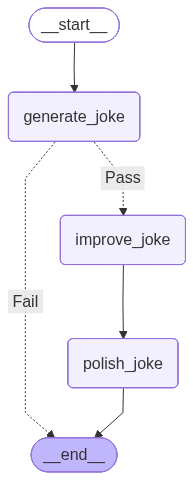

In [38]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build Workflow
workflow = StateGraph(State) 

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke) 

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", 
                               check_punchline,
                               {"Pass" : "improve_joke", "Fail" : END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [39]:
state = chain.invoke({"topic": "cats"})
print(state['joke'])
if "improve_joke" in state : 
    print(" The joke had a punchline, so it was improved. ")
    print(state['improve_joke'])
    
    print(" The improved joke was polished with a surprising twist. ")
    print(state['final_joke'])
else :  
    print("The joke did not have a punchline, so it was not improved.")


Why was the cat sitting on the computer?

He wanted to keep an eye on the **mouse**!
 The joke had a punchline, so it was improved. 
To improve this joke, you can play with the double meaning of "mouse" or "web," or add a little more flavor to the setup. Here are a few ways to level it up depending on what kind of humor you’re looking for:

**The "Tech-Savvy" Approach (Focusing on the mouse pun):**
> "Why was the cat sitting on the computer? He wanted to make sure the mouse didn't get away!"

**The "Modern/Relatable" Approach (Adding a layer of truth):**
> "Why was the cat sitting on the keyboard? He heard there was a mouse, but he was disappointed to find out it was just a cursor."

**The "Short & Punchy" Approach (Better timing):**
> "Why was the cat staring at the computer? He was waiting for the mouse to move."

**The "Tech Support" Approach (A bit more observational):**
> "Why does my cat insist on sitting on my laptop? I think he's trying to catch the mouse, but he’s just deletin

# Orchestrator-Worker
오케스트레이터는 작업을 분배하고 분배된 sub-task를 sub-worker에게 위임한다.

In [40]:
from pydantic import BaseModel, Field
from typing import Annotated, List
import operator

# Schema for structured output to use in plannging
class Section(BaseModel) : 
    name: str = Field(description="Name for this section of the report")
    description: str = Field(description="Brief overview of the main topics and concepts to be covered in this section. ")

class Sections(BaseModel) : 
    sections: List[Section] = Field(description="Sections for the report")

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [41]:
# Graph state
class State(TypedDict) : 
    topic: str
    sections: List[Section]
    # 내가 알기론 Annotated는 타입에 메타데이터(설명)을 추가하는데 여기서는 operator.add를 메타데이터로 추가하였다.  
    # langchain에서 Annotated는 상태의 특정 필드가 어떻게 업데이트되어야 하는지를 나타내는데 사용된다. + 메서드를 개발하여 상태의 필드가 어떻게 업데이트되어야 하는지를 정의할 수 있다.
    # completed_sections는 여러 worker 결과가 누적되는 필드다.
    completed_sections: Annotated[
        list, operator.add
    ]
    final_report: str
    
# Worker state
class WorkerState(TypedDict) : 
    section : Section
    completed_sections: Annotated[list, operator.add]

In [42]:
# SystemMessage 는 모델에게 주는 지침 
# HumanMessage 는 사용자의 질문/요청
from langchain_core.messages import SystemMessage, HumanMessage

# Send는 워크들을 동적으로 생성하여 실행시키는 객체
from langgraph.types import Send


def orchestrator(state: State) : 
    """Orchestrator that generates a plan for the report"""
    
    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the section report topic: {state['topic']}")
        ]
    )
    
    return {"sections": report_sections.sections}

def llm_call(state: WorkerState) : 
    """Worker writes a section of the report"""
    section = llm.invoke(
        [
            SystemMessage(content = "Write a report section."),
            HumanMessage(
                content=f"Here is the section name : {state['section'].name} and description: {state['section'].description}"
            )
        ]
    )
    
    return {"completed_sections": [section.text]}

def synthesizer(state: State) : 
    """ Synthesizer full report from sections """
    
    # List of completed sections
    completed_sections = state["completed_sections"]
    
    completed_report_sections = "\n\n---\n\n".join(completed_sections) 
    
    return {"final_report" : completed_report_sections}

def assign_workers(state : State) :
    """ Assign a worker to each section in the plan"""
    
    return [Send("llm_call", {"section" : s}) for s in state["sections"]]

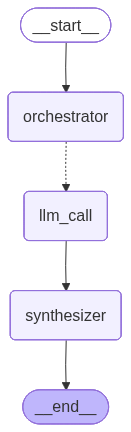

In [43]:

orchestrator_worker_builder = StateGraph(State) 
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call) 
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)

orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)    

orchestrator_worker = orchestrator_worker_builder.compile()

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [44]:
state = orchestrator_worker.invoke({"topic": "The impact of climate change on global agriculture."})

In [45]:
state["sections"]

[Section(name='Introduction', description='An overview of climate change as a global phenomenon and its general relationship with agricultural systems.'),
 Section(name='Direct Impacts on Crop Yields', description='Analysis of how shifting temperature patterns, altered precipitation, and extreme weather events affect major staple crops.'),
 Section(name='Soil Health and Water Scarcity', description='Evaluation of how drought, salinity, and soil degradation due to climate variability compromise land productivity.'),
 Section(name='Pests, Diseases, and Biodiversity', description='Examination of how changing climates expand the range of agricultural pests and pathogens while threatening beneficial pollinators.'),
 Section(name='Socioeconomic Consequences', description='Assessment of the impact on food security, commodity pricing, and the livelihoods of small-scale farmers in vulnerable regions.'),
 Section(name='Adaptation and Mitigation Strategies', description='Discussion on sustainable

In [46]:
from IPython.display import Markdown
Markdown(state["final_report"])

### 1. Introduction and Description: Climate Change and Global Agriculture

Climate change stands as one of the most critical challenges of the 21st century, representing a fundamental shift in Earth’s atmospheric composition and meteorological patterns. Driven primarily by the anthropogenic emission of greenhouse gases—such as carbon dioxide, methane, and nitrous oxide—this global phenomenon manifests through rising mean temperatures, altered precipitation regimes, and an increased frequency of extreme weather events, including prolonged droughts, catastrophic floods, and intensified heatwaves.

The relationship between climate change and agricultural systems is both profound and inherently bidirectional. Agriculture is uniquely sensitive to climate variability; because crop and livestock productivity rely heavily on stable environmental conditions, even marginal shifts in temperature and water availability can disrupt planting cycles, diminish yields, and compromise food security. Changes in thermal regimes are already shifting the geographical suitability of certain crops, moving growing seasons, and altering the distribution of pests and pathogens, which places unprecedented stress on established farming infrastructures.

Conversely, the agricultural sector serves as a significant contributor to the drivers of climate change. Industrial agricultural practices—ranging from intensive land-use conversion and deforestation to enteric fermentation in livestock and the heavy reliance on synthetic fertilizers—contribute a substantial portion of global greenhouse gas emissions. 

As the global population continues to rise, the tension between maintaining agricultural output and mitigating environmental degradation becomes more acute. This report examines the specific mechanisms through which climatic shifts impact agricultural productivity and explores the imperative for adaptive, sustainable strategies designed to bolster the resilience of global food systems in an increasingly volatile climate.

---

### Direct Impacts on Crop Yields

The stability of global food security is increasingly challenged by the direct biophysical effects of climate change on staple crop production. As temperature patterns shift, precipitation regimes become more erratic, and extreme weather events increase in frequency, the physiological development of major staples—such as wheat, maize, rice, and soy—is being disrupted at critical growth stages.

#### Thermal Stress and Phenological Shifts
Rising mean temperatures accelerate the phenological development of many crops, resulting in shorter growth cycles that limit the time available for biomass accumulation and grain filling. For temperature-sensitive staples like wheat and maize, exposure to extreme heat during reproductive stages—specifically anthesis and grain-filling—leads to impaired fertilization, flower abortion, and reduced kernel weight. These "heat shocks" can cause substantial yield contractions, even in regions otherwise suited for high-intensity agriculture.

#### Altered Precipitation and Hydrological Stress
Changes in the timing, intensity, and spatial distribution of precipitation represent a primary volatility factor for rain-fed agriculture. Increased variability in rainfall often manifests as prolonged dry spells during critical vegetative stages, resulting in moisture stress that stunts growth and lowers yield potential. Conversely, excessive rainfall and associated soil saturation can inhibit root development, promote fungal pathogens, and complicate mechanical harvesting, further exacerbating seasonal losses. The net result is a widening "yield gap" between current actual production and the theoretical genetic potential of these crops.

#### Escalation of Extreme Weather Events
The increasing frequency of extreme climate events—including intense droughts, heatwaves, and catastrophic flooding—presents a compounding risk to staple crop yields. Unlike gradual climatic shifts, these discrete events can cause total crop failure within a single growing season. For instance, severe droughts during the pollination phase in maize can lead to near-complete yield collapse. Furthermore, the convergence of multiple stress factors (e.g., heatwaves coinciding with water scarcity) creates synergistic effects that often exceed the adaptive capacity of traditional crop varieties.

#### Implications for Food Stability
The cumulative impact of these environmental stressors is a notable increase in year-to-year yield variability. This volatility poses a systemic risk to the global supply chain, as major breadbasket regions face synchronized climate stressors that threaten simultaneous production declines. As shifting climatic envelopes continue to alter the geographical suitability for staple crops, the agricultural sector faces an urgent mandate to integrate climate-resilient cultivars and adaptive water management strategies to mitigate these direct impacts on yields.

---

## 4.3 Soil Health and Water Scarcity

The stability of agricultural productivity is currently threatened by a synergistic decline in soil health and the intensifying crisis of water scarcity. Climate variability—manifested through prolonged drought cycles and erratic precipitation patterns—has fundamentally altered the hydrological and biological functions of arable land, creating a feedback loop that undermines food security.

### 4.3.1 Drought-Induced Degradation
Prolonged drought periods accelerate the physical and chemical degradation of soil. The loss of soil moisture diminishes the activity of the soil microbiome, which is essential for nutrient cycling and organic matter decomposition. As soil dries, it becomes prone to structural collapse and compaction, reducing infiltration rates and increasing susceptibility to wind erosion. This degradation cycle leaves land less capable of retaining the moisture that *is* available, effectively amplifying the impact of even minor rainfall deficits.

### 4.3.2 Salinization and Irrigation Stress
Water scarcity has forced a reliance on marginal-quality water sources, including treated wastewater and groundwater with high mineral content. In arid and semi-arid regions, the combination of high evapotranspiration rates and the application of low-quality irrigation water leads to rapid salt accumulation in the root zone. This secondary salinization creates osmotic stress, preventing plants from absorbing water regardless of irrigation efforts. Once soil salinity exceeds critical thresholds, the toxic buildup of ions degrades soil structure, leading to dispersion and a permanent loss of permeability, which often renders land unsuitable for traditional crop cultivation.

### 4.3.3 The Feedback Loop of Land Productivity
The intersection of these stressors results in a compounding loss of land productivity:
*   **Nutrient Depletion:** Reduced soil moisture limits the movement of nutrients to the root zone, leading to nutrient mining by crops.
*   **Loss of Soil Organic Carbon (SOC):** Climate variability reduces biomass production, which in turn reduces the carbon input into the soil. This depletes the soil’s natural carbon sink, lowering its ability to hold water and resist erosion.
*   **Biological Simplification:** The combination of salinity and dehydration selects against beneficial soil organisms, reducing the soil’s resilience to pests and disease.

Ultimately, the degradation of soil health acts as a multiplier for the effects of water scarcity. As soil health declines, the efficiency of irrigation decreases, requiring even more water to achieve the same yield—a requirement that is increasingly unsustainable under current climate projections. Addressing these challenges requires a shift toward regenerative practices, such as the use of salt-tolerant crop varieties, improved soil moisture conservation techniques, and integrated water management strategies that prioritize soil health as the foundation of hydrological resilience.

---

### Pests, Diseases, and Biodiversity

The accelerating pace of climate change is fundamentally restructuring the biotic pressures facing agricultural systems. As temperature profiles shift and precipitation patterns become increasingly erratic, the geographical distribution of agricultural pests and pathogens is expanding, often moving poleward or into higher altitudes previously protected by cooler climates. Concurrently, these same environmental stressors are destabilizing the delicate balance of biodiversity necessary for ecosystem resilience, specifically threatening the viability of beneficial pollinators.

#### Range Expansion of Pests and Pathogens
Warmer winter temperatures have significantly reduced the "cold-kill" threshold that historically limited the overwintering success of many agricultural pests. Species such as the fall armyworm (*Spodoptera frugiperda*) and various aphid vectors are now establishing permanent populations in temperate regions that were previously too harsh for their survival. This northward expansion is coupled with an increased number of reproductive cycles per season, leading to more frequent and intense pest outbreaks.

Furthermore, climate-induced physiological stress in host crops often compromises their natural defense mechanisms. Changes in humidity and altered rainfall patterns create microclimates that are highly conducive to the proliferation of fungal pathogens and viral vectors. The emergence of these diseases in non-endemic areas poses a severe threat to food security, as local varieties often lack the evolutionary resistance to these encroaching biological threats.

#### Threats to Beneficial Pollinators
While pest populations are expanding, the organisms that provide essential ecosystem services—most notably pollinators—are facing existential challenges. Climate change induces "phenological mismatch," a phenomenon where the timing of plant flowering and the emergence or migration of pollinators fall out of synchronization. When flowers bloom earlier than expected due to unseasonable warmth, pollinators may arrive too late to forage, leading to reproductive failure for both the plants and the insects.

Moreover, rising temperatures and prolonged droughts are shrinking the availability of high-quality floral resources. Habitat fragmentation, exacerbated by land-use changes necessitated by shifting agricultural zones, further isolates pollinator populations, reducing genetic diversity and making them more susceptible to the very pests and pathogens that are expanding in range. 

#### Implications for Agricultural Resilience
The convergence of these trends creates a destabilizing feedback loop. As farmers rely more heavily on broad-spectrum pesticides to manage expanding pest populations, they inadvertently exacerbate the decline of beneficial insects, further undermining pollination and biological pest control services. Moving forward, agricultural management must shift toward integrated, resilient strategies that prioritize the restoration of biodiversity as a primary defense against the encroaching threats of climate-driven pest and pathogen migration.

---

## Socioeconomic Consequences

The multifaceted challenges examined in this report extend beyond technical and environmental domains, manifesting in profound socioeconomic disruptions. The convergence of supply chain volatility, climate stressors, and market instability has created a cascading effect on food security, commodity pricing, and the economic viability of small-scale farming operations, particularly in vulnerable regions.

### Impact on Food Security
The primary consequence of current regional instabilities is the erosion of food security among low-income and rural populations. As local production is hampered by resource scarcity and infrastructure deficits, reliance on imported staples has increased. This dependence leaves vulnerable regions susceptible to global price shocks, often resulting in diminished dietary diversity and rising rates of malnutrition. In communities where household income is predominantly allocated to food procurement, even marginal increases in commodity costs significantly reduce caloric intake and exacerbate poverty traps.

### Commodity Pricing Volatility
Commodity markets have experienced heightened volatility, driven by localized production failures and logistical bottlenecks. For small-scale farmers, this unpredictability undermines long-term economic planning and investment. While sudden spikes in commodity prices may offer temporary windfalls for some producers, they are frequently offset by disproportionate increases in the cost of essential inputs—such as fertilizers, fuel, and seeds. The resulting "price squeeze" diminishes net profitability and discourages the adoption of modern, sustainable agricultural practices, trapping many producers in a cycle of subsistence-level farming.

### Livelihoods of Small-Scale Farmers
Small-scale farmers, who constitute the backbone of agriculture in vulnerable regions, remain the most exposed demographic to socioeconomic volatility. These producers often operate with limited access to credit, insurance, or formal market safety nets. When confronted with adverse environmental conditions or collapsing market prices, they lack the capital reserves necessary to absorb losses, frequently leading to:
*   **Asset Depletion:** The forced sale of productive assets (e.g., livestock or machinery) to cover immediate subsistence needs.
*   **Out-migration:** A trend of rural-to-urban migration as agricultural livelihoods become untenable, placing additional pressure on already strained urban infrastructure.
*   **Increased Debt Burdens:** Reliance on informal, high-interest lending mechanisms to finance subsequent planting seasons, which undermines long-term financial independence.

In conclusion, the socioeconomic consequences of these factors are mutually reinforcing, creating a systemic barrier to development. Addressing these challenges requires not only technical interventions but also integrated policy frameworks that prioritize social safety nets, equitable market access, and the financial resilience of small-scale producers.

---

## Adaptation and Mitigation Strategies

Building climate-resilient agriculture requires a multi-dimensional approach that integrates ecological stewardship, cutting-edge technology, and robust policy frameworks. To safeguard global food security against increasing climatic volatility, the following strategies must be implemented concurrently.

### Sustainable Farming Practices
The transition toward climate-resilient agriculture begins with regenerative practices that restore soil health and enhance the adaptive capacity of ecosystems. Key strategies include:
*   **Conservation Agriculture:** Implementing minimal soil disturbance, permanent soil cover, and crop diversification (crop rotation and intercropping) to improve soil structure and moisture retention.
*   **Agroforestry:** Integrating trees and shrubs into agricultural landscapes to provide shade, reduce wind erosion, and sequester atmospheric carbon.
*   **Water Management:** Scaling up precision irrigation techniques, such as drip and sprinkler systems, alongside the use of drought-tolerant crop varieties to optimize water use efficiency in water-stressed regions.

### Technological Innovations
Technology acts as a force multiplier for adaptation, allowing farmers to make data-driven decisions in the face of uncertainty. Current innovations include:
*   **Precision Agriculture:** Utilizing IoT sensors, satellite imagery, and AI-driven analytics to monitor soil health, crop growth, and pest pressure in real-time. This ensures that inputs—such as fertilizers and water—are applied only where and when necessary, reducing waste and environmental impact.
*   **Biotechnology and Plant Breeding:** Accelerating the development of climate-smart crop varieties that exhibit enhanced resilience to heat stress, salinity, and extreme weather events through advanced genomic tools like CRISPR.
*   **Digital Extension Services:** Deploying mobile-based platforms to provide smallholder farmers with hyper-local weather forecasting, early-warning systems for pests, and real-time market access, thereby reducing vulnerability to climate-induced yield loss.

### Policy Frameworks
Technological and agronomic solutions cannot succeed without a supportive policy landscape that incentivizes sustainable transitions. Effective governance must focus on:
*   **Incentive Mechanisms:** Establishing carbon credit markets and "Payments for Ecosystem Services" (PES) programs that financially reward farmers for carbon sequestration and biodiversity conservation.
*   **Risk Mitigation and Insurance:** Developing scalable crop insurance products that utilize parametric triggers, ensuring that farmers receive rapid payouts following extreme weather events, thereby preventing long-term asset depletion.
*   **Infrastructure and Supply Chain Support:** Investing in climate-proof infrastructure, such as cold-chain storage and resilient transport networks, to minimize post-harvest losses and ensure food availability during climate-induced supply chain disruptions.
*   **Knowledge Exchange and Capacity Building:** Strengthening extension services and promoting collaborative research partnerships between academic institutions, private industry, and farming communities to ensure that innovations are accessible, culturally appropriate, and effectively deployed.

By aligning these adaptation and mitigation strategies, the agricultural sector can shift from being a significant driver of climate change to becoming a central pillar of the global climate solution.

---

### 6. Conclusion and Outlook

#### 6.1 Summary of Findings
The analysis presented in this report underscores the multidimensional nature of the current global food crisis. Our findings indicate that food insecurity is no longer a localized issue confined to developing regions; rather, it is a systemic vulnerability exacerbated by the convergence of climate-induced crop failures, geopolitical instability, and supply chain fragility. Data suggests that current agricultural production models are struggling to keep pace with rapid population growth, further constrained by diminishing soil health and inefficient water management. Consequently, the reliance on fragmented national policies has proven inadequate in addressing the volatility of international food markets, leaving the most vulnerable populations at perpetual risk of malnutrition and economic instability.

#### 6.2 The Necessity for Global Cooperation
The complexity of these challenges dictates that no single nation can achieve food sovereignty in isolation. Future food stability necessitates a fundamental shift toward an integrated, globally cooperative framework. This cooperation must prioritize three critical pillars:

*   **Knowledge and Technology Exchange:** Accelerating the democratization of climate-smart agricultural technologies to improve yields in high-risk zones, ensuring that scientific advancements are shared rather than siloed.
*   **Coordinated Supply Chain Resilience:** Establishing international protocols for trade and logistics that prevent protectionist measures during times of crisis, thereby ensuring that food staples remain accessible regardless of regional disruptions.
*   **Unified Climate Adaptation Strategies:** Aligning global policy to mitigate the long-term environmental degradation of arable land. Without a collective commitment to sustainable resource management, the baseline for food production will continue to erode.

Looking ahead, the outlook for future food stability remains precarious but manageable, provided there is a transition from reactive emergency interventions to proactive, multilateral structural reform. Global cooperation is not merely an ethical imperative; it is a pragmatic necessity for maintaining international security, economic prosperity, and the fundamental right to nutrition in an increasingly interconnected world.

# Evaluator - Optimzer

In [47]:
from pydantic import BaseModel, Field
from typing import Literal

class Feedback(BaseModel) : 
    grade: Literal["funny", "not funny"] = Field(
        description = "Decide if the joke is funny or not."
    )
    feedback: str = Field(description = "If the joke is not funny, provide feedback on how to improve it.")
    
evaluator = llm.with_structured_output(Feedback)

In [48]:
from typing_extensions import TypedDict
# Graph State
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [49]:
def llm_call_generator(state: State) : 
    """ LLM generates a joke """
    
    if state.get("feedback") : 
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else : 
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.text}

def llm_call_evaluator(state: State) : 
    """ LLM evaluates the joke """
    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# conditional edge funtion to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State) : 
    """ Route back to joke generator or end based upon feedback from the evaluator """
    
    if state["funny_or_not"] == "funny" : 
        return "Accepted"
    elif state["funny_or_not"] == "not funny": 
        return "Rejected + Feedback"

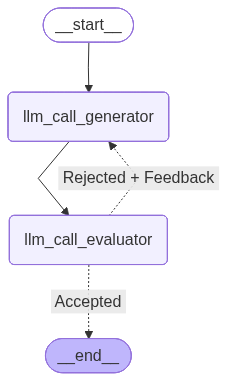

In [50]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator) 
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator", 
    route_joke,
    {"Accepted": END,
     "Rejected + Feedback": "llm_call_generator"}
)

# Compile the workflow
optimizer = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer.get_graph().draw_mermaid_png()))

In [51]:
state = optimizer.invoke({"topic": "Korean"})
print(state["joke"])

In my office, we treat the legacy database like a revered Korean elder at a family banquet: we bow before we touch the server, we never address a query without first offering a digital gift of extra RAM, and we pray to the ancestors that the architecture doesn't decide to disown us.

Last Tuesday, the database finally reached its breaking point. It didn't just crash; it staged a cultural revolution. The system went offline, and as I frantically tried to reboot the partition, the error log didn't give me a standard failure code. Instead, it popped up a message that effectively read: *"I have brought shame upon this house, and now I must commit honorable seppuku via total disk corruption."*

I spent three hours manually restoring the tables, while my manager stood behind me, sighing with the heavy, disappointed gravity of a grandmother watching me try to eat kimchi with a fork.


In [52]:
print(state["funny_or_not"])

funny


# Agent

In [53]:
from langchain_core.tools import tool

# Define tools
@tool
def multiply(a: int, b: int) -> int : 
    """ Multiply a and b. 
        Args:
            a: first int
            b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int : 
    """ Add a and b.
        Args:
            a: first int
            b: second int
    """
    return a+b

@tool
def divide(a: int, b: int) -> int : 
    """ Divide a by b.
        Args:
            a: first int
            b: second int
    """
    if b == 0 : 
        return "Error: Division by zero"
    return a/b

tools = [multiply, add, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

for tool in tools : 
    print(f"Tool name: {tool.name}, Tool description: {tool.description}")

Tool name: multiply, Tool description: Multiply a and b. 
       Args:
           a: first int
           b: second int
Tool name: add, Tool description: Add a and b.
       Args:
           a: first int
           b: second int
Tool name: divide, Tool description: Divide a by b.
       Args:
           a: first int
           b: second int


In [54]:
from langgraph.graph import MessagesState
from langchain_core.messages import ToolMessage, HumanMessage, SystemMessage

# nodes
def llm_call(state: MessagesState) : 
    """ LLM decides whether to call a tool or not"""
    
    return {
        "messages" : [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are helpful assistant tasked with performing arithmetic on a set of inputs"
                    )
                ]
                + state["messages"]
            )
        ]
    }
    
def tool_node(state: dict) : 
    """Performs the tool call"""
    
    result = []
    for tool_call in state["messages"][-1].tool_calls : 
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


def should_continue(state: MessagesState) -> Literal["Action", "END"]: 
    """ Decide if we should continue the loop or stop based upon whether"""
    
    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, them perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop (reply to the user) 
    return END

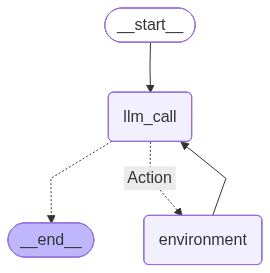

In [55]:
agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", 
                                    should_continue, 
                               {"Action": "environment", END: END})
agent_builder.add_edge("environment", "llm_call")

agent = agent_builder.compile()

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [57]:
messages = [HumanMessage(content="Add 3 and 5. Then, take the output and multiply it by 2.")]
messages = agent.invoke({"messages" : messages})
for m in messages["messages"] : 
    m.pretty_print()

================================ Human Message =================================

Add 3 and 5. Then, take the output and multiply it by 2.
================================== Ai Message ==================================

[]
Tool Calls:
  add (b1a70c2b-f1ae-4e84-8c39-0ef76a4d6d2a)
 Call ID: b1a70c2b-f1ae-4e84-8c39-0ef76a4d6d2a
  Args:
    b: 5
    a: 3
================================= Tool Message =================================

8
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (72f3ee88-f834-4654-8cbd-dd6dbcf44bf5)
 Call ID: 72f3ee88-f834-4654-8cbd-dd6dbcf44bf5
  Args:
    b: 2
    a: 8
================================= Tool Message =================================

16
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of adding 3 and 5 is 8, and multiplying that by 2 gives 16.', 'extras': {'signature': 'EjQKMgEMOdbHhjK/YysZGcx4ClLSK7X9UuZWbFZj+wsuixo+IQ

In [1]:
from deepagents import create_deep_agent
from dotenv import load_dotenv
load_dotenv()

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_deep_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='7341f968-4a75-4100-baae-375788ffee39'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "sf"}'}, '__gemini_function_call_thought_signatures__': {'c8430111-4119-4fcd-b01c-46dc3d9c9c67': 'EjQKMgEMOdbHikUHP4K62lzo3JXqGg62p+5XomwC3VJzei/cB/ivIv9mHdl1sfFMTStwpWB9'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5e00-d92a-7451-b6c7-412ad6e76231-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'sf'}, 'id': 'c8430111-4119-4fcd-b01c-46dc3d9c9c67', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5776, 'output_tokens': 16, 'total_tokens': 5792, 'input_token_details': {'cache_read': 4046}}),
  ToolMessage(content="It's always sunny in sf!", name='get_weather', id='5e555d24-5bcd-43b1-